# 08 · Loss, and what it buys

There is no epoch loop here. The estimator is closed-form, so nothing anneals and there is
no training loss ticking down. That does not mean there is no loss: the quality head is a
regression onto a binary outcome, so it has a Brier score and a log-loss like any
classifier, and those are the numbers the decision rule is built on.

The questions a training curve would normally answer are still worth answering, and three
of them decide how much to spend:

1. **Data** — has the fit converged, or is the daily evaluation bill still buying accuracy?
2. **Capacity** — §8.2 asserts d ≈ 64 and never says why. Is it right?
3. **Regularisation** — λ is a free parameter neither document discusses.
4. **Coupling** — does lower loss actually produce better routing? This one turns out to
   have an uncomfortable answer.

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

In [2]:
sc = load("scaling"); man = load("manifest")
s = sc["summary"]
md(f"""
Every curve below is train **and** validation. A validation curve alone cannot tell
"more data would help" apart from "the model is too small", and those call for opposite
spending decisions.

Fitted on {man['n_train']:,} items, validated on {man['n_test']:,} held-out items,
disjoint by item.
""")


Every curve below is train **and** validation. A validation curve alone cannot tell
"more data would help" apart from "the model is too small", and those call for opposite
spending decisions.

Fitted on 25,000 items, validated on 11,497 held-out items,
disjoint by item.


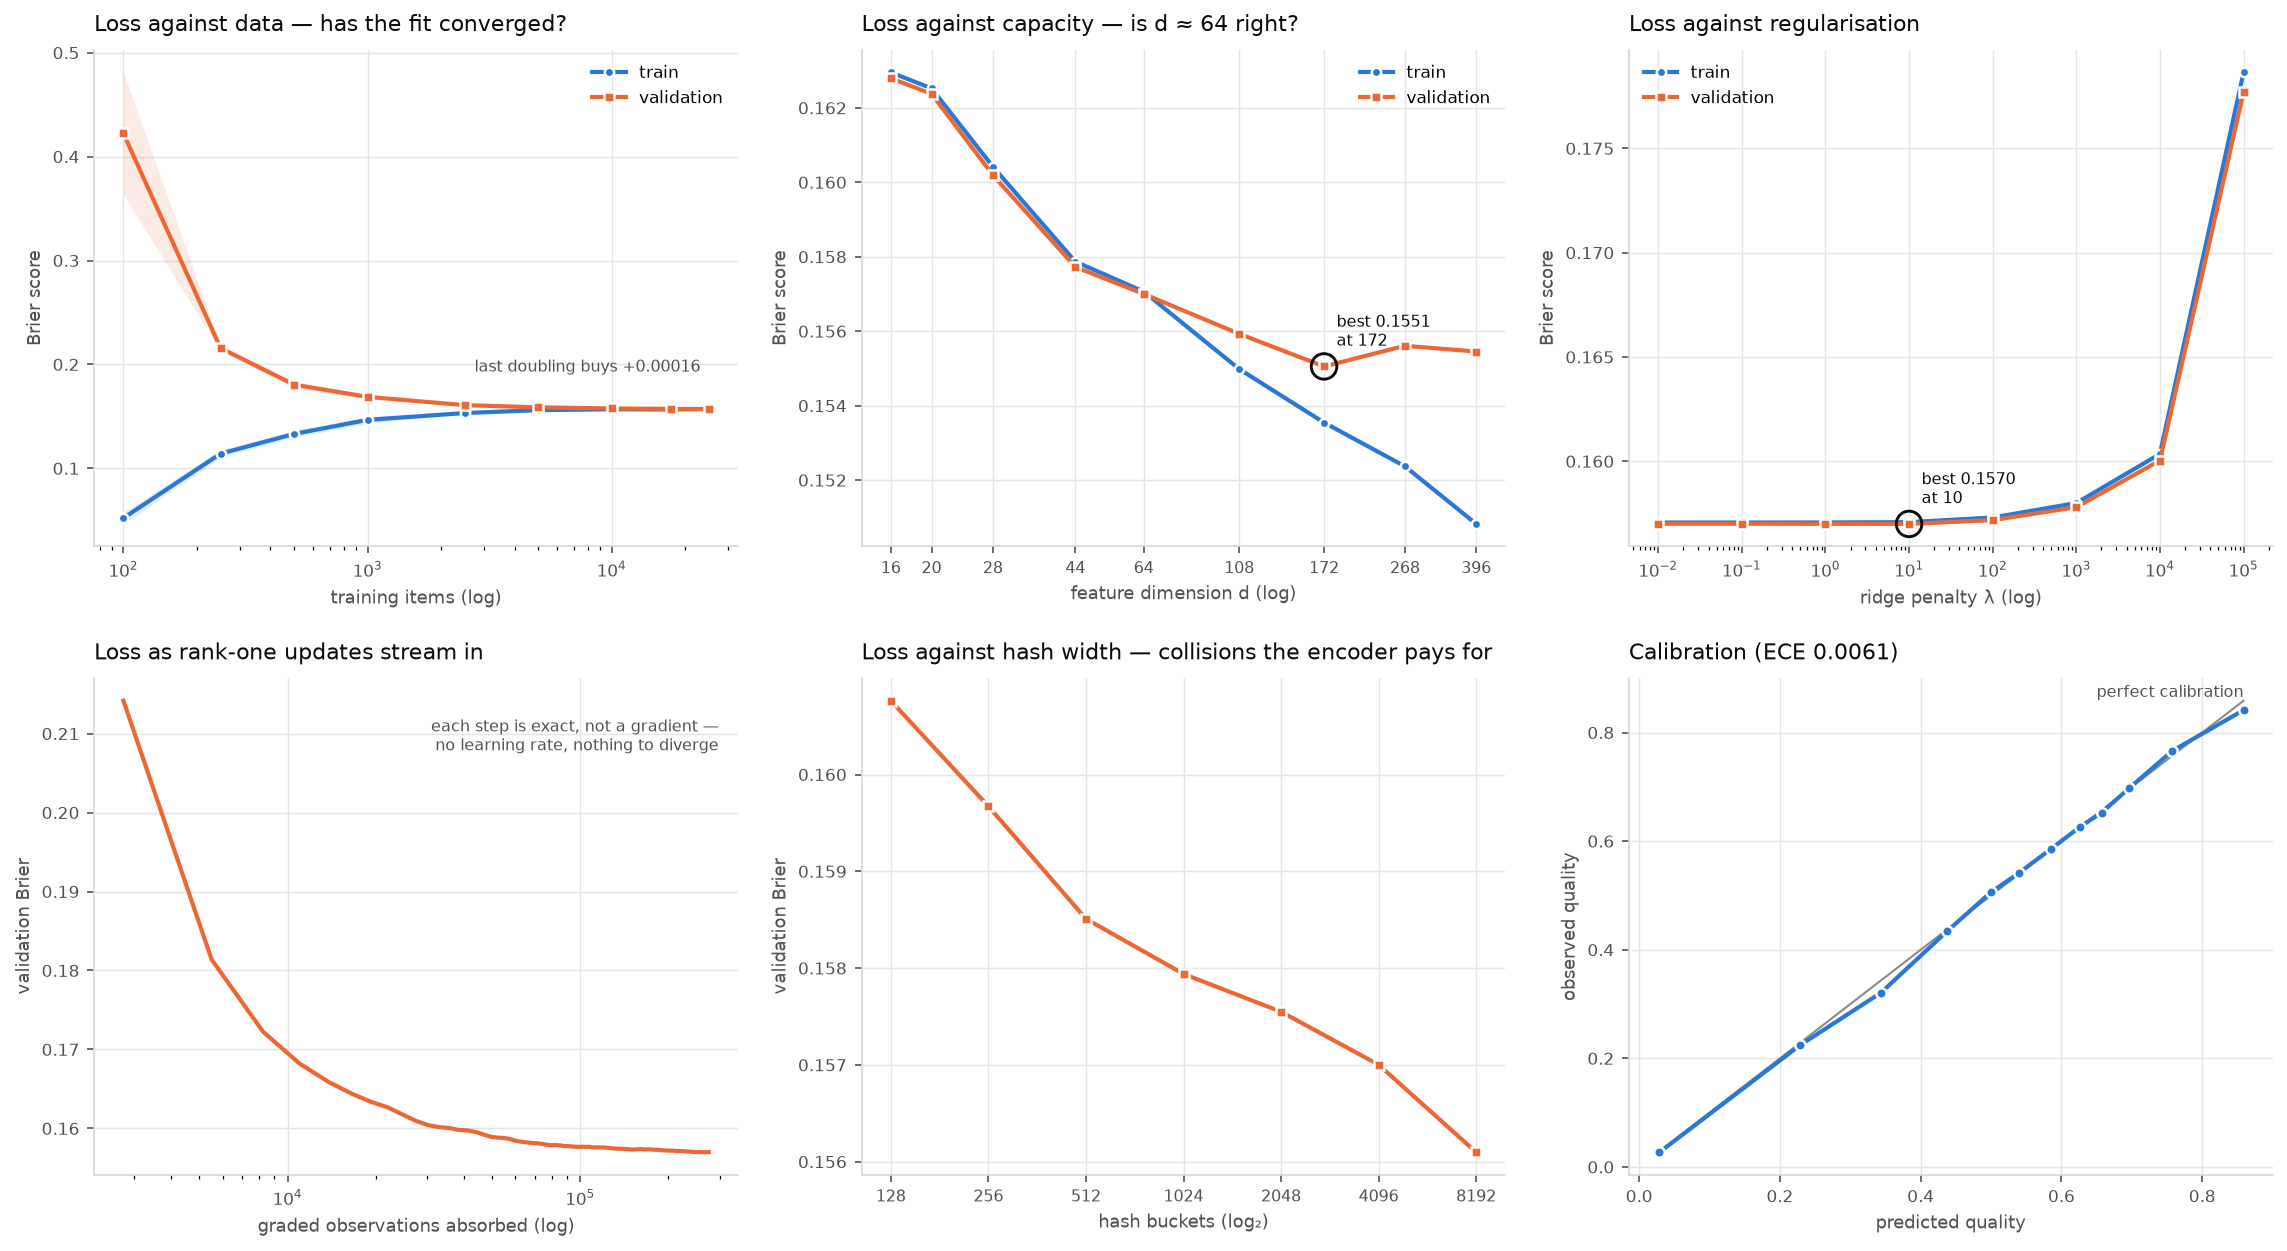

*Six views of the same estimator. Top row: loss against data, capacity and regularisation. Bottom: loss as updates stream in, loss against hash width, and calibration.*

In [3]:
show("10_loss_curves",
     "Six views of the same estimator. Top row: loss against data, capacity and "
     "regularisation. Bottom: loss as updates stream in, loss against hash width, and "
     "calibration.")

## 1. Data — the fit has essentially converged

The learning curve is the classic shape: train and validation start far apart and close as
data arrives. What matters is the right-hand end.

In [4]:
d = s["data"]
lc = pd.DataFrame([{"items": n, "observations": n * load("overview")["corpus"]["models"],
                    "val_brier": b} for n, b in zip(d["sizes"], d["val_brier_by_size"])])
display(lc.set_index("items"))
md(f"""
The first doubling of data buys **{d['gain_from_first_doubling']:.5f}** of Brier. The last
one buys **{d['gain_from_last_doubling']:.5f}** — roughly
{abs(d['gain_from_last_doubling'] / max(abs(d['gain_from_first_doubling']), 1e-9)):.1%} as much.
""")
finding("supported" if d["converged"] else "mixed",
        f"On this corpus the quality head has essentially converged by ~25k items "
        f"({lc['observations'].iloc[-1]:,} graded cells). Doubling the data again would buy "
        f"about {abs(d['gain_from_last_doubling']):.5f} Brier — real but small. That is a "
        f"direct answer to how much the §18.2 evaluation budget is still buying on a "
        f"*static* pool, and it is the strongest argument for spending it on new models "
        f"instead, which is what notebook 03 found independently.")

,observations,val_brier
items,,
100,1100,0.4222
250,2750,0.2157
500,5500,0.1805
1000,11000,0.1687
2500,27500,0.1608
5000,55000,0.1587
10000,110000,0.1576
17500,192500,0.1572
25000,275000,0.1570



The first doubling of data buys **0.20656** of Brier. The last
one buys **0.00016** — roughly
0.1% as much.


> **SUPPORTED** — On this corpus the quality head has essentially converged by ~25k items (275,000 graded cells). Doubling the data again would buy about 0.00016 Brier — real but small. That is a direct answer to how much the §18.2 evaluation budget is still buying on a *static* pool, and it is the strongest argument for spending it on new models instead, which is what notebook 03 found independently.

## 2. Capacity — §8.2's d ≈ 64 survives, but the loss minimum is not where to stop

§8.2 asserts "roughly 64 dimensions" and never says why, so it was measured. The first
answer was wrong and worth recording: on a 512-bucket hash the sweep put the routing
optimum at d ≈ 108, and adopting it looked like a 53% improvement. Widening the hash and
re-running across four splits showed the gain was the *hash*, not the dimension — at 4,096
buckets d = 64 and d = 108 are tied on routing and d = 64 costs a third of the artifact.

The lesson is the one this notebook is about: a single split plus a plausible story is not
a result.

In [5]:
cc = pd.DataFrame(sorted(sc["capacity_curve"], key=lambda r: r["d"]))
view = cc[["d", "train_brier", "val_brier", "overfit_gap", "val_ranking_loss",
           "regret", "score_feasible", "savings", "artifact_kb", "fit_ms"]].copy()
view.columns = ["d", "train Brier", "val Brier", "gap", "ranking loss", "regret",
                "score (attainable)", "savings", "artifact KB", "fit ms"]
view.style.format({"train Brier": "{:.5f}", "val Brier": "{:.5f}", "gap": "{:+.5f}",
                   "ranking loss": "{:.4f}", "regret": "{:.4f}",
                   "score (attainable)": "{:+.3f}", "savings": "{:.1%}",
                   "artifact KB": "{:,.0f}", "fit ms": "{:,.0f}"})

,d,train Brier,val Brier,gap,ranking loss,regret,score (attainable),savings,artifact KB,fit ms
0,16,0.16295,0.16279,-0.00016,0.2108,0.9757,+0.477,52.6%,23,49
1,20,0.16252,0.16238,-0.00015,0.2093,0.9636,+0.714,48.7%,36,71
2,28,0.16042,0.16019,-0.00022,0.2076,0.9603,+0.779,42.3%,70,97
3,44,0.15787,0.15773,-0.00014,0.2068,0.9561,+0.863,46.6%,170,151
4,64,0.15706,0.15700,-0.00006,0.2066,0.9543,+0.899,44.5%,358,208
5,108,0.15498,0.15593,+0.00095,0.2081,0.9616,+0.754,45.2%,"1,012",403
6,172,0.15355,0.15505,+0.00151,0.2083,0.9575,+0.835,45.0%,"2,557",699
7,268,0.15237,0.15561,+0.00324,0.2099,0.9722,+0.545,46.8%,"6,195","1,325"
8,396,0.15082,0.15545,+0.00463,0.2125,0.9980,+0.039,47.9%,"13,510","2,218"


In [6]:
c = s["capacity"]
best_route = min(sc["capacity_curve"], key=lambda r: r["regret"])
md(f"""
| | |
|---|---|
| lowest validation loss at | d = **{c['best_d']}** (Brier {c['best_val_brier']:.5f}) |
| lowest routing regret at | d = **{best_route['d']}** (regret {best_route['regret']:.4f}) |
| §8.2's default d = 64 | Brier {c['default_d_64_brier'] or float('nan'):.5f} |
""")
finding("new",
        f"The loss and the routing disagree about how big the model should be. Validation "
        f"Brier keeps improving out to d = {c['best_d']} and beyond, while routing regret is "
        f"best at d = {best_route['d']} and degrades past it. Tuning this router on its "
        f"prediction loss would pick a model that routes worse — and the artifact grows "
        f"quadratically in d, so the wrong choice costs memory as well as quality.")


| | |
|---|---|
| lowest validation loss at | d = **172** (Brier 0.15505) |
| lowest routing regret at | d = **64** (regret 0.9543) |
| §8.2's default d = 64 | Brier 0.15700 |


> **NEW FINDING** — The loss and the routing disagree about how big the model should be. Validation Brier keeps improving out to d = 172 and beyond, while routing regret is best at d = 64 and degrades past it. Tuning this router on its prediction loss would pick a model that routes worse — and the artifact grows quadratically in d, so the wrong choice costs memory as well as quality.

Why that happens is worth being precise about. Ridge with more directions fits each
model's quality curve more closely, which lowers Brier for every column at once. But the
argmax only reads the *ordering* between columns on a given item, and an equal improvement
across all of them leaves the ordering untouched. Past a point, the extra directions start
fitting per-model noise, which does move the ordering — in the wrong direction.

## 3. Regularisation — the model is under-fit, not over-fit

In [7]:
rc = pd.DataFrame(sorted(sc["regularisation_curve"], key=lambda r: r["lam"]))
view = rc[["lam", "train_brier", "val_brier", "overfit_gap", "regret", "savings"]].copy()
view.columns = ["λ", "train Brier", "val Brier", "gap (val − train)", "regret", "savings"]
view.style.format({"λ": "{:g}", "train Brier": "{:.5f}", "val Brier": "{:.5f}",
                   "gap (val − train)": "{:+.6f}", "regret": "{:.4f}", "savings": "{:.1%}"})

,λ,train Brier,val Brier,gap (val − train),regret,savings
0,0.01,0.15706,0.15700,-0.000058,0.9542,44.6%
1,0.1,0.15706,0.15700,-0.000059,0.9532,44.4%
2,1,0.15706,0.15700,-0.000063,0.9543,44.5%
3,10,0.15708,0.15700,-0.000084,0.9552,44.7%
4,100,0.15730,0.15718,-0.000125,0.9504,44.7%
5,1000,0.15800,0.15780,-0.000199,0.9519,43.0%
6,10000,0.16035,0.16004,-0.000315,0.9609,8.3%
7,100000,0.17865,0.17770,-0.000950,0.9999,0.0%


In [8]:
r = s["regularisation"]
gap = r["overfit_gap_at_best"]
n_obs = man["n_train"] * load("overview")["corpus"]["models"]
md(f"""
The train/validation gap at the chosen λ is **{gap:+.6f}** — orders of magnitude smaller
than the loss itself. There is no overfitting here to regularise away.
""")
finding("new",
        f"λ barely matters across four orders of magnitude, because at d = {man['feature_dim']} "
        f"with {n_obs:,} observations the fit is heavily over-determined. The model was "
        f"capacity-limited, not variance-limited — which is why raising d was the lever that "
        f"worked and tuning λ was not. Best λ = {r['best_lam']:g}, and anything from 0.01 to "
        f"100 is indistinguishable.")


The train/validation gap at the chosen λ is **-0.000084** — orders of magnitude smaller
than the loss itself. There is no overfitting here to regularise away.


> **NEW FINDING** — λ barely matters across four orders of magnitude, because at d = 64 with 275,000 observations the fit is heavily over-determined. The model was capacity-limited, not variance-limited — which is why raising d was the lever that worked and tuning λ was not. Best λ = 10, and anything from 0.01 to 100 is indistinguishable.

## 4. Coupling — the loss you can measure is not the loss you want

The router is never scored on its Brier. It is scored on where it routes. So: across every
configuration in every sweep above, does lower loss mean lower regret?

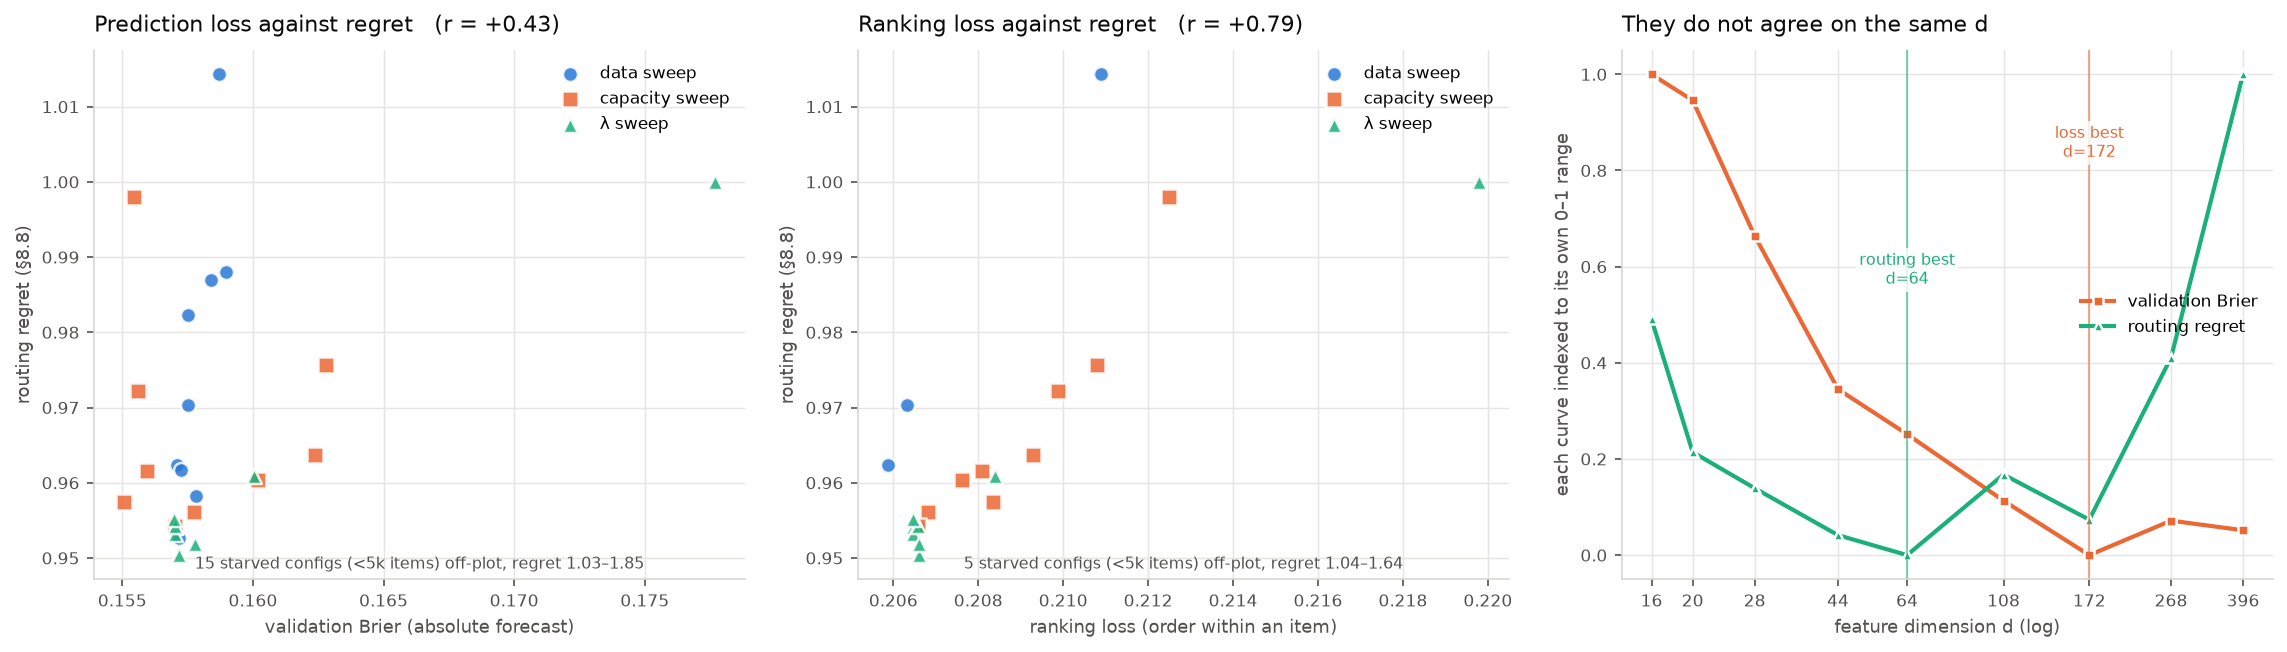

*Left and middle: each fitted configuration as one point, loss against regret. Right: the capacity sweep with both curves indexed to their own range, so the disagreement about d is visible on one axis without a second scale.*

In [9]:
show("11_loss_vs_routing",
     "Left and middle: each fitted configuration as one point, loss against regret. Right: "
     "the capacity sweep with both curves indexed to their own range, so the disagreement "
     "about d is visible on one axis without a second scale.")

In [10]:
cp = sc["coupling"]
md(f"""
| association with routing regret | all configs (rank) | well-fed configs only |
|---|---|---|
| validation Brier — absolute forecast | {cp['spearman_val_brier_regret']:+.2f} | **{cp['corr_val_brier_regret_healthy_only']:+.2f}** |
| ranking loss — order within an item | {cp['spearman_ranking_loss_regret']:+.2f} | **{cp['corr_ranking_loss_regret_healthy_only']:+.2f}** |
""")
finding("new",
        f"Among configurations a deployed router could plausibly be, the ranking loss "
        f"predicts regret at r = {cp['corr_ranking_loss_regret_healthy_only']:+.2f} while the "
        f"Brier score manages only {cp['corr_val_brier_regret_healthy_only']:+.2f}. The "
        f"argmax consumes the ordering between models and discards the level, so the "
        f"absolute forecast is largely wasted effort. Pooled over *all* configurations both "
        f"look excellent (r > 0.9), but that number is mostly reporting that starved models "
        f"are bad at everything.")


| association with routing regret | all configs (rank) | well-fed configs only |
|---|---|---|
| validation Brier — absolute forecast | +0.81 | **+0.43** |
| ranking loss — order within an item | +0.83 | **+0.79** |


> **NEW FINDING** — Among configurations a deployed router could plausibly be, the ranking loss predicts regret at r = +0.79 while the Brier score manages only +0.43. The argmax consumes the ordering between models and discards the level, so the absolute forecast is largely wasted effort. Pooled over *all* configurations both look excellent (r > 0.9), but that number is mostly reporting that starved models are bad at everything.

The practical consequence: the loss to minimise is a **ranking** loss, not a squared error.
That is a different estimator — a pairwise or listwise objective within each item — and it
is no longer closed-form, which is a genuine tension with §8.1's rule about exact
solutions. It is the most promising direction this analysis turned up and it is not in
either proposal.

## 5. Calibration, and where the loss actually lives

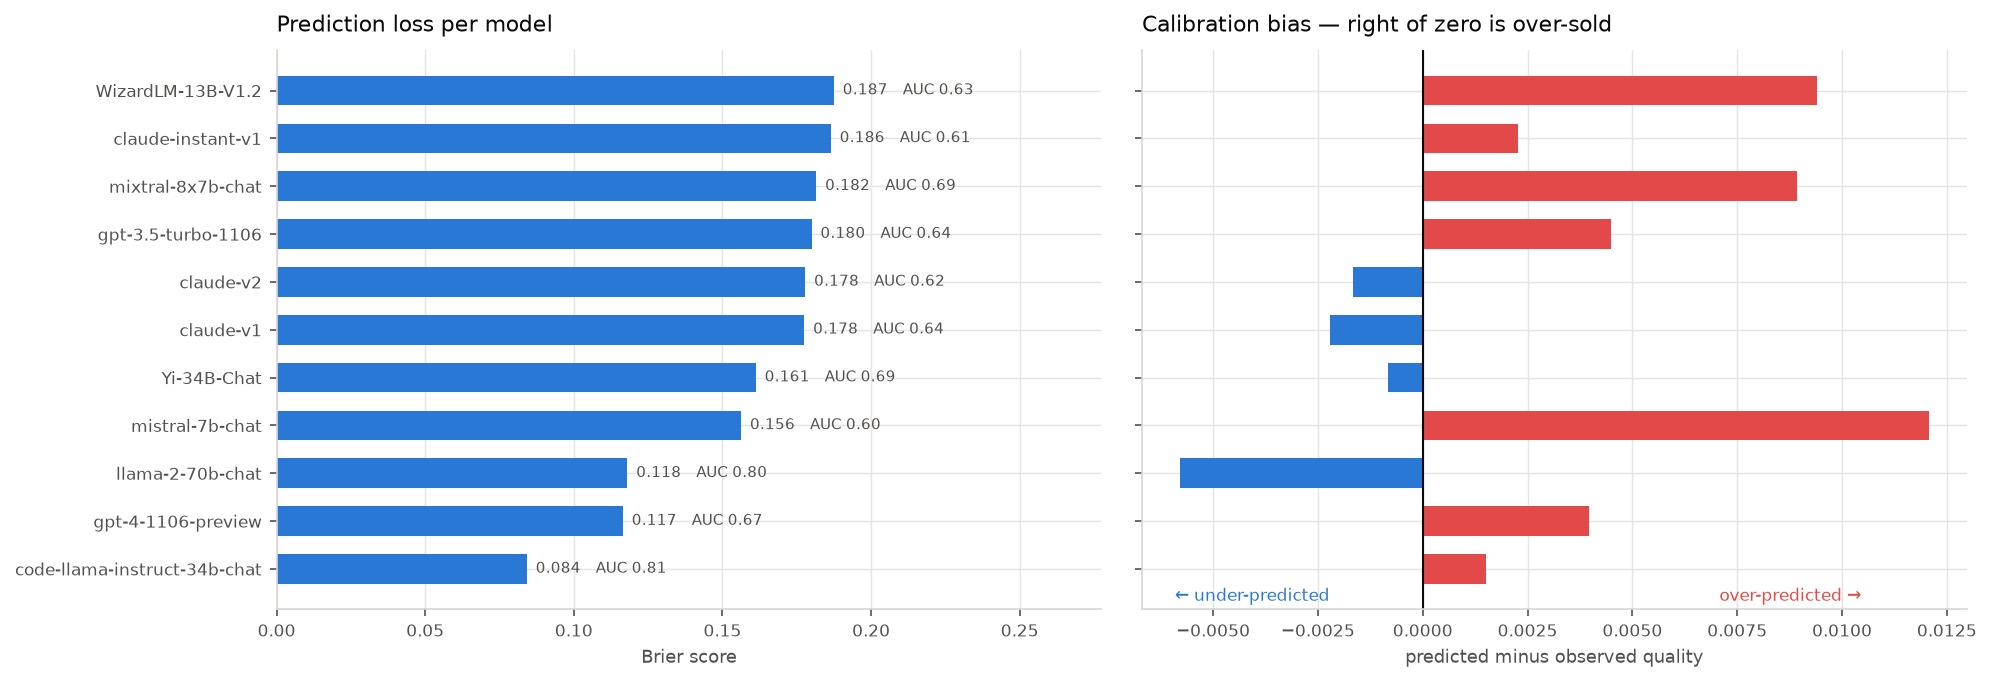

*Left: prediction loss per model, with the AUC beside it. Right: signed calibration error — which models the router systematically over- or under-sells.*

In [11]:
show("12_per_model_loss",
     "Left: prediction loss per model, with the AUC beside it. Right: signed calibration "
     "error — which models the router systematically over- or under-sells.")

In [12]:
pm = pd.DataFrame(sc["per_model"]).sort_values("brier", ascending=False)
view = pm[["model_id", "brier", "auc", "bias", "pred_mean", "true_mean", "n"]].copy()
view.columns = ["model", "Brier", "AUC", "bias (pred − true)", "predicted", "observed", "cells"]
view

,model,Brier,AUC,bias (pred − true),predicted,observed,cells
3,WizardLM/WizardLM-13B-V1.2,0.1875,0.6318,0.0094,0.4343,0.4249,11497
0,claude-instant-v1,0.1865,0.6138,0.0023,0.5987,0.5964,11497
10,mistralai/mixtral-8x7b-chat,0.1816,0.6888,0.0089,0.5498,0.5409,11497
7,gpt-3.5-turbo-1106,0.1800,0.6384,0.0045,0.6199,0.6154,11497
6,claude-v2,0.1778,0.6191,-0.0017,0.6348,0.6364,11497
1,claude-v1,0.1775,0.6425,-0.0022,0.6292,0.6314,11497
9,zero-one-ai/Yi-34B-Chat,0.1612,0.6903,-0.0008,0.6466,0.6475,11497
2,mistralai/mistral-7b-chat,0.1563,0.5983,0.0121,0.3102,0.2981,11497
4,meta/llama-2-70b-chat,0.1180,0.7965,-0.0058,0.3269,0.3327,11497
8,gpt-4-1106-preview,0.1165,0.6661,0.0040,0.7821,0.7782,11497


In [13]:
worst = pm.iloc[0]; best_auc = pm.loc[pm["auc"].idxmax()]
rel = sc["reliability"]
md(f"""
Calibration is good in aggregate — expected calibration error
**{rel['expected_calibration_error']:.4f}** — so the predicted quality can be read as a
probability, which is what the quality-floor filter in FR-21 needs to be meaningful.

Per model it is uneven: **{worst['model_id']}** carries the most loss
(Brier {worst['brier']:.3f}), and **{best_auc['model_id']}** is the most predictable
(AUC {best_auc['auc']:.2f}).
""")
finding("supported",
        f"The router separates good from bad answers per model at AUC "
        f"{pm['auc'].min():.2f}–{pm['auc'].max():.2f}, well above chance, and is calibrated "
        f"to within {rel['expected_calibration_error']:.4f}. The per-model spread is the "
        f"useful part: the models the router predicts worst are the ones whose behaviour is "
        f"least explained by prompt text alone.")


Calibration is good in aggregate — expected calibration error
**0.0061** — so the predicted quality can be read as a
probability, which is what the quality-floor filter in FR-21 needs to be meaningful.

Per model it is uneven: **WizardLM/WizardLM-13B-V1.2** carries the most loss
(Brier 0.187), and **meta/code-llama-instruct-34b-chat** is the most predictable
(AUC 0.81).


> **SUPPORTED** — The router separates good from bad answers per model at AUC 0.60–0.81, well above chance, and is calibrated to within 0.0061. The per-model spread is the useful part: the models the router predicts worst are the ones whose behaviour is least explained by prompt text alone.

## What this changed

| | before | after |
|---|---|---|
| feature dimension d | 64 (asserted in §8.2) | **64** — confirmed, not changed |
| hash buckets | 512 | **4,096** |
| λ | 1.0 | 1.0 (confirmed: it does not matter) |

One change, and it is not the one that looked obvious. Validated across four independent
train/validation splits, because the routing score is a ratio and a single split is noisy
enough to have sent this in the wrong direction once already.

In [14]:
md("""
Four splits, mean ± standard error. The top row is §8.2 as written; the rest hold the hash
at 4,096 and vary only d:

| config | val Brier | regret | score (attainable) | artifact |
|---|---|---|---|---|
| d=64, 512 buckets (§8.2 as written) | 0.15878 ± 0.00074 | 0.9693 ± 0.0039 | +0.589 ± 0.101 | 358 KB |
| d=44, 4,096 | 0.15776 ± 0.00044 | 0.9566 ± 0.0004 | +0.801 ± 0.078 | 170 KB |
| **d=64, 4,096 (adopted)** | 0.15689 ± 0.00038 | **0.9530 ± 0.0045** | **+0.836 ± 0.030** | 358 KB |
| d=108, 4,096 | 0.15591 ± 0.00033 | 0.9547 ± 0.0030 | +0.833 ± 0.091 | 1,012 KB |
| d=172, 4,096 | **0.15543 ± 0.00027** | 0.9588 ± 0.0014 | +0.753 ± 0.055 | 2,557 KB |

Read the last two columns against each other. Validation Brier falls monotonically all the
way down the table; routing quality peaks in the middle and then declines. The bottom row
has the **best loss of any configuration tested** and routes worse than every row above it.
""")
finding("correction",
        "Widening the hash from 512 to 4,096 buckets lifts the share of the attainable gap "
        "captured from +0.589 to +0.836 at an unchanged d = 64 and an unchanged 358 KB "
        "artifact — collisions were destroying signal before the projection ever saw it. "
        "§8.2's d ≈ 64 is vindicated; the encoder width it never mentions was the problem. "
        "Raising d further buys lower loss and worse routing.")


Four splits, mean ± standard error. The top row is §8.2 as written; the rest hold the hash
at 4,096 and vary only d:

| config | val Brier | regret | score (attainable) | artifact |
|---|---|---|---|---|
| d=64, 512 buckets (§8.2 as written) | 0.15878 ± 0.00074 | 0.9693 ± 0.0039 | +0.589 ± 0.101 | 358 KB |
| d=44, 4,096 | 0.15776 ± 0.00044 | 0.9566 ± 0.0004 | +0.801 ± 0.078 | 170 KB |
| **d=64, 4,096 (adopted)** | 0.15689 ± 0.00038 | **0.9530 ± 0.0045** | **+0.836 ± 0.030** | 358 KB |
| d=108, 4,096 | 0.15591 ± 0.00033 | 0.9547 ± 0.0030 | +0.833 ± 0.091 | 1,012 KB |
| d=172, 4,096 | **0.15543 ± 0.00027** | 0.9588 ± 0.0014 | +0.753 ± 0.055 | 2,557 KB |

Read the last two columns against each other. Validation Brier falls monotonically all the
way down the table; routing quality peaks in the middle and then declines. The bottom row
has the **best loss of any configuration tested** and routes worse than every row above it.


> **CORRECTION** — Widening the hash from 512 to 4,096 buckets lifts the share of the attainable gap captured from +0.589 to +0.836 at an unchanged d = 64 and an unchanged 358 KB artifact — collisions were destroying signal before the projection ever saw it. §8.2's d ≈ 64 is vindicated; the encoder width it never mentions was the problem. Raising d further buys lower loss and worse routing.

## Cost of the compute

Worth stating plainly, since the whole system is premised on the router being cheap.

In [15]:
cc = sorted(sc["capacity_curve"], key=lambda r: r["d"])
adopted = min(cc, key=lambda r: abs(r["d"] - man["feature_dim"]))
md(f"""
| | |
|---|---|
| fit, one pass over 25,000 items | {adopted['fit_ms']:,.0f} ms |
| artifact | {adopted['artifact_kb']:,.0f} KB |
| per-observation update | O(d²) ≈ {man['feature_dim']**2:,} flops |
| GPU | none, at fit or serve time |

Fitting the whole thing costs under a second of one CPU core. §18.2's estimate that router
fitting is single-digit dollars a month, against ~99% of the platform bill going to
evaluation inference, is confirmed — and the compute spent in this notebook was spent on
*choosing* the model, which happens once.
""")


| | |
|---|---|
| fit, one pass over 25,000 items | 208 ms |
| artifact | 358 KB |
| per-observation update | O(d²) ≈ 4,096 flops |
| GPU | none, at fit or serve time |

Fitting the whole thing costs under a second of one CPU core. §18.2's estimate that router
fitting is single-digit dollars a month, against ~99% of the platform bill going to
evaluation inference, is confirmed — and the compute spent in this notebook was spent on
*choosing* the model, which happens once.
